# Bronze Layer — Raw Screenshot Preprocessing

Welcome to the **Bronze Layer** of the Game State Vision Predictor.

## Where Are We in the Pipeline?

```
Raw Screenshot  ──►  [BRONZE]  ──►  [SILVER]  ──►  [GOLD]  ──►  Prediction
                      (you are here)   (EDA)         (model)
```

The Bronze layer is the **entry point**. It takes a raw game screenshot and runs
OpenCV preprocessing (denoising, contrast enhancement, sharpening) to produce a
clean image that downstream layers can work with.

## What This Notebook Will Show

1. Load a raw screenshot and validate its shape
2. Walk through each preprocessing step visually
3. Compare histograms before and after
4. Extract summary metadata
5. Save the artifacts to disk

---

In [1]:
import sys
from pathlib import Path

PROJECT_ROOT = Path.cwd().parent
sys.path.insert(0, str(PROJECT_ROOT))

import json

import cv2
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns

from src.config import BRONZE_DIR, SILVER_DIR
from src.pipeline.bronze import (
    H, W,
    denoise,
    enhance_contrast,
    extract_metadata,
    load_image,
    preprocess,
    process_image,
    sharpen,
)

sns.set_theme(style="darkgrid")
%matplotlib inline

## 1.  Discover Screenshots

We scan the `data/bronze/` directory for PNG files. Any raw game screenshot placed
there will be picked up automatically — no hardcoded paths needed.

In [3]:
SCREENSHOT_DIR = BRONZE_DIR
OUTPUT_DIR = SILVER_DIR

pngs = sorted(SCREENSHOT_DIR.glob("*.png"))
if not pngs:
    raise FileNotFoundError(
        f"No PNG screenshots found in {SCREENSHOT_DIR}.\n"
        "Place game screenshots in data/bronze/ and restart."
    )

print(f"Found {len(pngs)} screenshot(s)")
print(f"Using: {pngs[1].name}")
image_path = str(pngs[1])

Found 2 screenshot(s)
Using: test_screenshot.png


## 2.  Load & Validate

The `load_image()` function reads the screenshot from disk and enforces the
**shape contract**: `(H=1440, W=2560, 3)` for desktop resolution. If the image
differs, it is silently resized so downstream code always receives consistent
dimensions.

In [4]:
raw = load_image(image_path)

print(f"Shape  : {raw.shape}")
print(f"Dtype  : {raw.dtype}")
print(f"Min/Max: {raw.min()} / {raw.max()}")
print(f"Aspect correct: {raw.shape[1] / raw.shape[0]:.2f} (expected 16:9 = 1.78)")

Shape  : (1440, 2560, 3)
Dtype  : uint8
Min/Max: 0 / 255
Aspect correct: 1.78 (expected 16:9 = 1.78)


## 3.  Why Preprocess? — The "Why" Behind Each Step

Raw game screenshots contain **noise and compression artifacts** that confuse
downstream models. We apply three stages:

| Step | Method | Purpose |
|------|--------|---------|
| 1. Denoise | Non-Local Means | Remove sensor/compression noise while preserving edges |
| 2. Contrast | CLAHE on L-channel | Boost local contrast without amplifying noise in flat regions |
| 3. Sharpen | Unsharp mask | Restore edge definition softened by denoising |

Let's visualize each stage side by side.

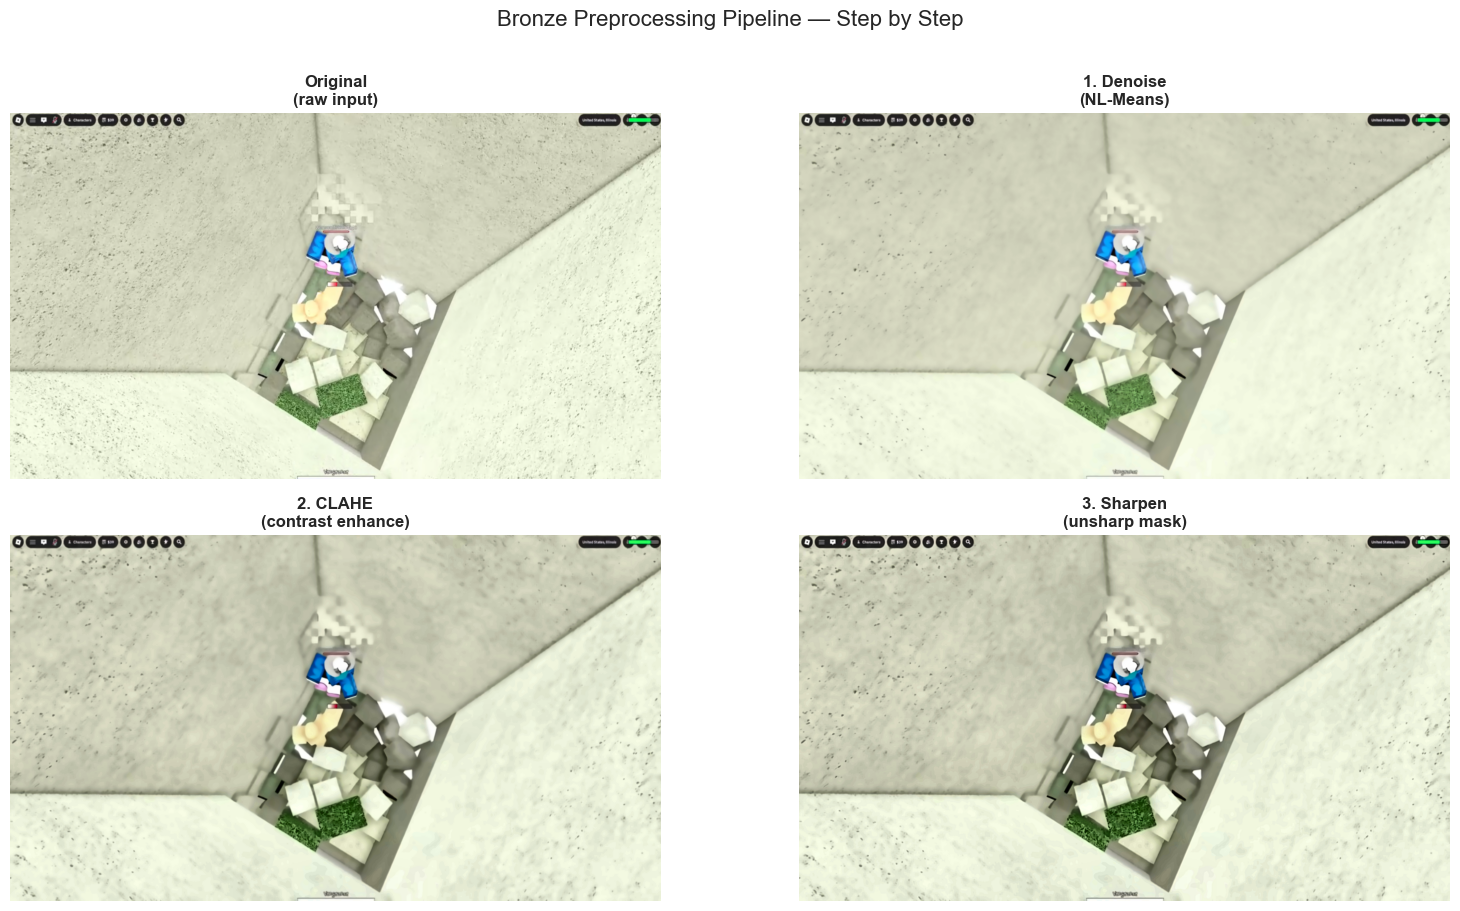

In [5]:
stages = {
    "Original\n(raw input)": raw,
    "1. Denoise\n(NL-Means)": denoise(raw),
    "2. CLAHE\n(contrast enhance)": enhance_contrast(denoise(raw)),
    "3. Sharpen\n(unsharp mask)": preprocess(raw),
}

fig, axes = plt.subplots(2, 2, figsize=(16, 9))
for ax, (title, img) in zip(axes.ravel(), stages.items()):
    ax.imshow(img)
    ax.set_title(title, fontsize=12, fontweight="bold")
    ax.axis("off")
fig.suptitle("Bronze Preprocessing Pipeline — Step by Step", fontsize=16, y=1.01)
plt.tight_layout()
plt.show()

## 4.  Per-Pixel Difference Map

Where did the pipeline actually change the image? We compute the absolute
difference between the original and the final preprocessed image. Brighter
regions in the heatmap indicate more aggressive modification.

Mean per-pixel change : 9.80
Max  per-pixel change : 96


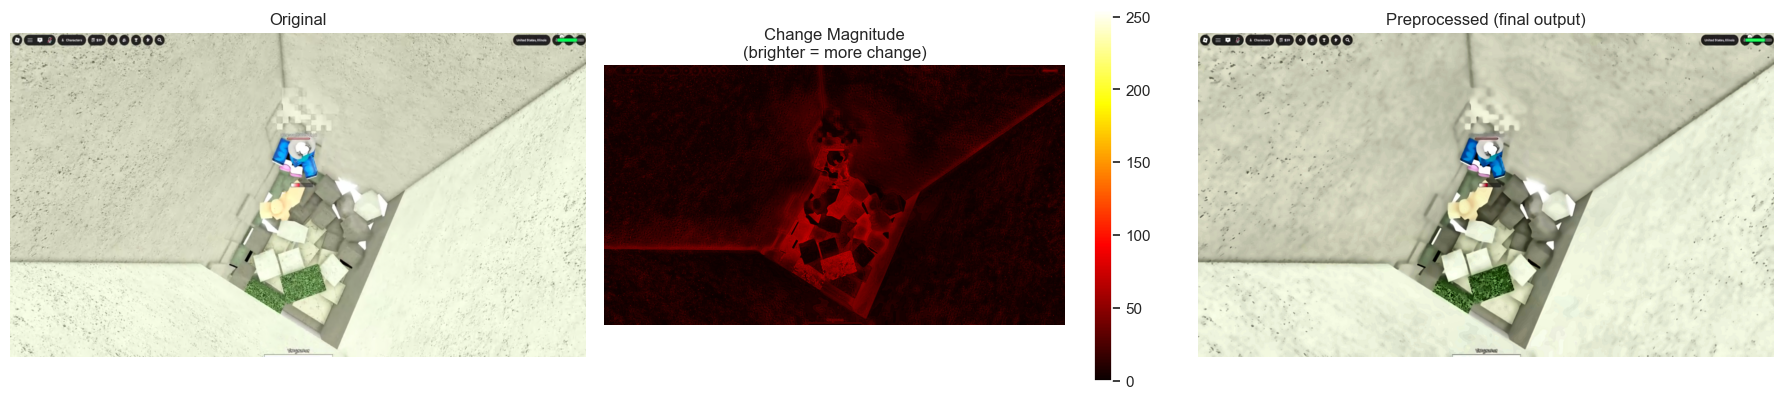

In [6]:
cleaned = preprocess(raw)
diff = np.abs(raw.astype(np.int16) - cleaned.astype(np.int16)).astype(np.uint8)
diff_gray = diff.max(axis=2)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

axes[0].imshow(raw)
axes[0].set_title("Original")
axes[0].axis("off")

im = axes[1].imshow(diff_gray, cmap="hot", vmin=0, vmax=255)
axes[1].set_title("Change Magnitude\n(brighter = more change)")
axes[1].axis("off")
plt.colorbar(im, ax=axes[1], shrink=0.8)

axes[2].imshow(cleaned)
axes[2].set_title("Preprocessed (final output)")
axes[2].axis("off")

print(f"Mean per-pixel change : {diff.mean():.2f}")
print(f"Max  per-pixel change : {diff.max()}")
plt.tight_layout()
plt.show()

## 5.  RGB Histogram Comparison

Histograms show how pixel intensities are distributed before and after
preprocessing. The CLAHE step stretches the histogram, making better use of
the full 0-255 range and improving contrast in dark/mid-tone regions.

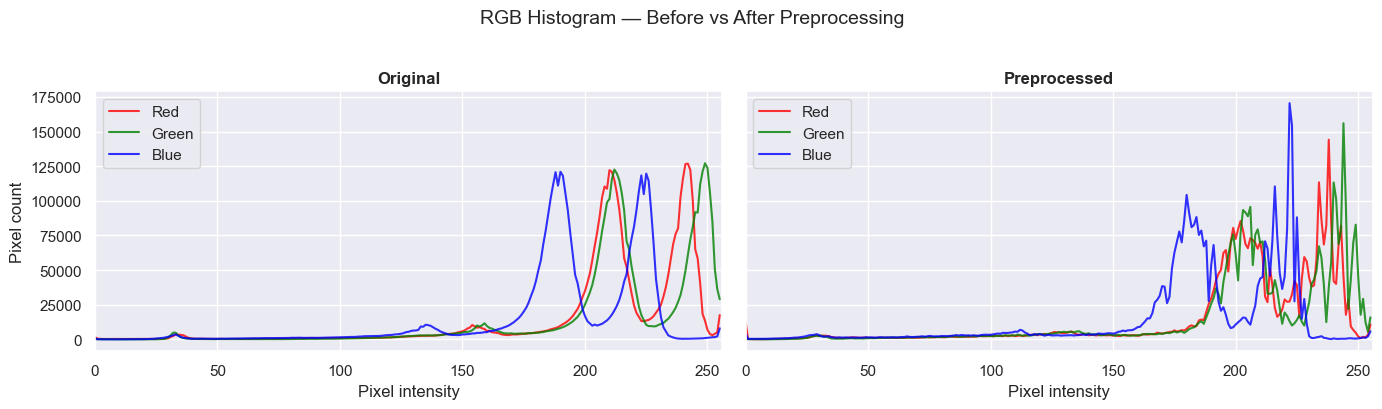

In [7]:
colors = ("Red", "Green", "Blue")
fig, axes = plt.subplots(1, 2, figsize=(14, 4), sharey=True)

for i, (img, title) in enumerate([(raw, "Original"), (cleaned, "Preprocessed")]):
    ax = axes[i]
    for c, color_name in enumerate(colors):
        hist = cv2.calcHist([img], [c], None, [256], [0, 256])
        ax.plot(hist, color=color_name.lower(), label=color_name, alpha=0.8)
    ax.set_title(title, fontweight="bold")
    ax.set_xlim(0, 256)
    ax.set_xlabel("Pixel intensity")
    if i == 0:
        ax.set_ylabel("Pixel count")
    ax.legend()

fig.suptitle("RGB Histogram — Before vs After Preprocessing", fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

## 6.  Summary Metadata

The `extract_metadata()` function computes basic statistics from the cleaned
image: mean brightness, standard deviation, and contrast. These are saved
alongside the image for reference in the Silver layer.

In [8]:
meta = extract_metadata(cleaned, image_path=str(Path(image_path).resolve()))
print(meta)

BronzeFeatures(image_path='C:\\Users\\Ryan Craft\\Documents\\Coding\\Game State Vision Predictor\\data\\bronze\\test_screenshot.png', mean_brightness=205.09462917751736, std_brightness=39.840030655865995, contrast=255.0, width=2560, height=1440, channels=3)


## 7.  End-to-End Processing

The `process_image()` function ties everything together:
1. Load the raw screenshot
2. Run the full preprocessing pipeline
3. Extract metadata
4. Save the preprocessed PNG and metadata JSON to `data/silver/`

These artifacts become the **input to the Silver layer**.

In [9]:
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
result = process_image(image_path, str(OUTPUT_DIR))

print(f"Preprocessed PNG : {result['preprocessed']}")
print(f"Metadata JSON    : {result['metadata']}")

with open(result["metadata"]) as f:
    saved_meta = json.load(f)
print(f"\nMetadata keys: {list(saved_meta.keys())}")

Preprocessed PNG : C:\Users\Ryan Craft\Documents\Coding\Game State Vision Predictor\data\silver\test_screenshot_bronze.png
Metadata JSON    : C:\Users\Ryan Craft\Documents\Coding\Game State Vision Predictor\data\silver\test_screenshot_bronze.json

Metadata keys: ['image_path', 'mean_brightness', 'std_brightness', 'contrast', 'width', 'height', 'channels']


## 8.  Round-Trip Verification

Confirm that the saved PNG reloads exactly as exported — no data corruption.

In [10]:
reloaded = load_image(result["preprocessed"])
np.testing.assert_array_equal(cleaned, reloaded)
print("✓ Round-trip assertion passed: saved == reloaded")

✓ Round-trip assertion passed: saved == reloaded


---

## Summary

The Bronze layer has:
- **Loaded** a raw screenshot ✓
- **Preprocessed** it (denoise → CLAHE → sharpen) ✓
- **Compared** before/after histograms and difference maps ✓
- **Extracted** summary metadata ✓
- **Saved** artifacts to `data/silver/` for the Silver layer ✓

Next step: open **`02_silver_eda.ipynb`** to see how a multi-head CNN extracts
game-relevant features (player health, enemy positions, attack/defense state)
from the cleaned image.